In [1]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,get_acronym,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 12
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

In [6]:
modelA = 'deepseek'
# modelA = 'llama'
modelB = modelA
language_pairs = [('english','spanish'),
                  ]
aux_A = 'source'
aux_B = 'target'

batch_shuffle = 0
min_token_length = 7
n_files = 20
batch_size = 100
Ns = batch_size*n_files
n_tokens_list = [min_token_length]
avg = 0
Nbits_list = [0]
idx = None
match_vars = ['matching','mismatching']
random_centers_list = [-1,0,1]

[]

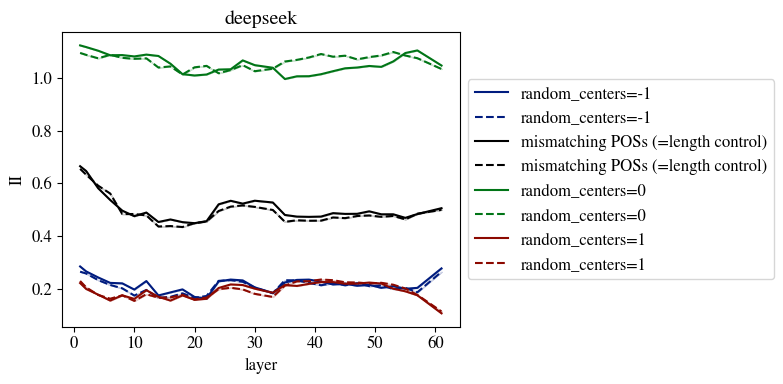

In [ ]:
fig,ax = plt.subplots(1,figsize=(8,4))

for random_centers_id,random_centers in enumerate(random_centers_list):
  for match_id,match_var in enumerate(match_vars):
    if match_var == 'mismatching' and random_centers != -1:
      continue
    for Nbits_id,Nbits in enumerate(Nbits_list):
      for language_pair_id, language_pair in enumerate(language_pairs):
        for n_tokens in n_tokens_list:
          (languageA,languageB) = language_pair
          output_folder0 = makefolder(base=f'./results/',
                                        create_folder=False,
                                        modelA=modelA,
                                        modelB=modelB,
                                        match_var=match_var,
                                        n_files=n_files,
                                        min_token_length=min_token_length,
                                        )
          II_folder = makefolder(base=output_folder0,
                                            create_folder=False,
                                            random_centers=random_centers,
                                            Nbits=Nbits,
                                            n_tokens=n_tokens,
                                            avg_tokens=avg,
                                            batch_shuffle=batch_shuffle,
                                            )
          inf_imb = np.load(II_folder + "II.npy")
          std = np.load(II_folder + "II_jack_std.npy")

          layers_A = list(range(1,depths[modelA] + 1))
          layers_B = list(range(1,depths[modelB] + 1))
          layers = reduce_list_half_preserve_extremes(layers_A)
          

          if 0: #match_var == 'mismatching':
            color = 'black'
            label = 'mismatching POSs (=length control)'
          else:
            color = colors[random_centers_id]
            label = f'{random_centers=}',
          for II_index in range(2):
            plt.plot(layers,
                     inf_imb[II_index].diagonal(),
                     label=label,
                     linestyle=_linestyles[II_index],
                     color=color,
                     ) 
            plt.fill_between(layers,
                            inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                            inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                            alpha=0.2,
                            color=color,
                            )

ax.legend()
ax.set_xlabel('layer')
ax.set_ylabel('II')
ax.set_title(f'{modelA}')


box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.plot()

### Similarities

In [6]:
layer_A = 1
layer_B = 1
method = 'min'
sim_folder = makefolder(base=output_folder0+f'similarities/',
                        create_folder=False,
                        Nbits=Nbits,
                        n_tokens=n_tokens,
                        avg_tokens=avg,
                        batch_shuffle=batch_shuffle,
                        layer_A=layer_A,
                        layer_B=layer_B,
                        )
II_fn = build_information_imbalance(k=1)

A_sim = np.load(os.path.join(sim_folder, "sim_A.npy"))
B_sim = np.load(os.path.join(sim_folder, "sim_B.npy")) 


FileNotFoundError: [Errno 2] No such file or directory: './results/modelA_llama/modelB_llama/match_var_mismatching/n_files_20/min_token_length_7/similarities/Nbits_0/n_tokens_7/avg_tokens_0/batch_shuffle_0/layer_A_1/layer_B_1/sim_A.npy'